<a href="https://colab.research.google.com/github/LGsekara1/Glove_Rejection_and_Inspection_Process_-GRIP-/blob/main/yolo_flop_profiler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO Hardware Requirements Profiler
**All versions: YOLOv1 to YOLOv10 + Fast-YOLO**

Profiles per model:
- **GFLOPs** — compute cost per forward pass
- **Parameters (M)** — model size
- **GMACs** — multiply-accumulate ops
- **Estimated VRAM (MB)** — FP32 weight memory
- **FPS / Latency** — throughput benchmark

Run cells top to bottom. Works on CPU or CUDA GPU (Colab T4 recommended).

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = ['torch', 'torchvision', 'thop', 'tabulate', 'pandas', 'matplotlib', 'seaborn', 'tqdm']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All dependencies installed.')

All dependencies installed.


## Cell 2 — YOLO Architecture Definitions

All models implemented from original papers.
References: YOLOv1 (Redmon 2016), YOLOv2 (Redmon 2017), YOLOv3 (Redmon 2018),
YOLOv4 (Bochkovskiy 2020), YOLOv5 (Ultralytics 2020), YOLOv6 (Li 2022),
YOLOv7 (Wang 2022), YOLOv8 (Ultralytics 2023), YOLOv9 (Wang 2024), YOLOv10 (Wang 2024).

In [2]:
import torch
import torch.nn as nn


# ── Shared helpers ────────────────────────────────────────────────────────────

def cba(ic, oc, k=3, s=1, p=1, act=None):
    """Conv -> BN -> Activation"""
    act = act if act is not None else nn.LeakyReLU(0.1, inplace=True)
    return nn.Sequential(nn.Conv2d(ic, oc, k, s, p, bias=False), nn.BatchNorm2d(oc), act)

def ca(ic, oc, k=3, s=1, p=1):
    """Conv -> LeakyReLU (no BN, YOLOv1 style)"""
    return nn.Sequential(nn.Conv2d(ic, oc, k, s, p, bias=True), nn.LeakyReLU(0.1, inplace=True))


# ── YOLOv1 ───────────────────────────────────────────────────────────────────
class YOLOv1(nn.Module):
    """YOLOv1 (Redmon et al., 2016) — 24 conv layers, 448x448 input."""
    def __init__(self, S=7, B=2, C=20):
        super().__init__()
        self.backbone = nn.Sequential(
            ca(3,64,7,2,3), nn.MaxPool2d(2,2),
            ca(64,192,3,1,1), nn.MaxPool2d(2,2),
            ca(192,128,1,1,0), ca(128,256,3,1,1), ca(256,256,1,1,0), ca(256,512,3,1,1), nn.MaxPool2d(2,2),
            ca(512,256,1,1,0), ca(256,512,3,1,1),
            ca(512,256,1,1,0), ca(256,512,3,1,1),
            ca(512,256,1,1,0), ca(256,512,3,1,1),
            ca(512,256,1,1,0), ca(256,512,3,1,1),
            ca(512,512,1,1,0), ca(512,1024,3,1,1), nn.MaxPool2d(2,2),
            ca(1024,512,1,1,0), ca(512,1024,3,1,1),
            ca(1024,512,1,1,0), ca(512,1024,3,1,1),
            ca(1024,1024,3,1,1), ca(1024,1024,3,2,1),
            ca(1024,1024,3,1,1), ca(1024,1024,3,1,1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024*S*S, 4096),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, S*S*(B*5+C)),
        )
    def forward(self, x): return self.head(self.backbone(x))


# ── Fast-YOLO ─────────────────────────────────────────────────────────────────
class FastYOLO(nn.Module):
    """Fast YOLO (Tiny YOLO, 2016) — 9 conv layers, 448x448 input."""
    def __init__(self, S=7, B=2, C=20):
        super().__init__()
        self.net = nn.Sequential(
            ca(3,16,3,1,1),   nn.MaxPool2d(2,2),
            ca(16,32,3,1,1),  nn.MaxPool2d(2,2),
            ca(32,64,3,1,1),  nn.MaxPool2d(2,2),
            ca(64,128,3,1,1), nn.MaxPool2d(2,2),
            ca(128,256,3,1,1),nn.MaxPool2d(2,2),
            ca(256,512,3,1,1),nn.MaxPool2d(2,2),
            ca(512,1024,3,1,1),
            ca(1024,1024,3,1,1),
            ca(1024,1024,3,1,1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024*S*S, S*S*(B*5+C)),
        )
    def forward(self, x): return self.head(self.net(x))


# ── YOLOv2 / Darknet-19 ───────────────────────────────────────────────────────
class YOLOv2(nn.Module):
    """YOLOv2 (Redmon 2017) — Darknet-19, BN everywhere, anchor boxes. 416x416."""
    def __init__(self, nc=80, na=5):
        super().__init__()
        self.net = nn.Sequential(
            cba(3,32,3,1,1),   nn.MaxPool2d(2,2),
            cba(32,64,3,1,1),  nn.MaxPool2d(2,2),
            cba(64,128,3,1,1), cba(128,64,1,1,0), cba(64,128,3,1,1), nn.MaxPool2d(2,2),
            cba(128,256,3,1,1),cba(256,128,1,1,0),cba(128,256,3,1,1),nn.MaxPool2d(2,2),
            cba(256,512,3,1,1),cba(512,256,1,1,0),cba(256,512,3,1,1),
            cba(512,256,1,1,0),cba(256,512,3,1,1),nn.MaxPool2d(2,2),
            cba(512,1024,3,1,1),cba(1024,512,1,1,0),cba(512,1024,3,1,1),
            cba(1024,512,1,1,0),cba(512,1024,3,1,1),
            cba(1024,1024,3,1,1),cba(1024,1024,3,1,1),
            nn.Conv2d(1024, na*(5+nc), 1),
        )
    def forward(self, x): return self.net(x)


# ── YOLOv3 / Darknet-53 ───────────────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.b = nn.Sequential(cba(c,c//2,1,1,0), cba(c//2,c,3,1,1))
    def forward(self, x): return x + self.b(x)

class YOLOv3(nn.Module):
    """YOLOv3 (Redmon 2018) — Darknet-53, residual blocks, 3-scale detection. 416x416."""
    def __init__(self, nc=80, na=3):
        super().__init__()
        oc = na*(5+nc)
        self.s1 = nn.Sequential(
            cba(3,32,3,1,1), cba(32,64,3,2,1), ResBlock(64),
            cba(64,128,3,2,1), *[ResBlock(128) for _ in range(2)],
            cba(128,256,3,2,1),*[ResBlock(256) for _ in range(8)],
        )
        self.s2 = nn.Sequential(cba(256,512,3,2,1), *[ResBlock(512) for _ in range(8)])
        self.s3 = nn.Sequential(cba(512,1024,3,2,1),*[ResBlock(1024) for _ in range(4)])
        def dh(ic, mc):
            return nn.Sequential(
                cba(ic,mc,1,1,0), cba(mc,mc*2,3,1,1),
                cba(mc*2,mc,1,1,0), cba(mc,mc*2,3,1,1),
                cba(mc*2,mc,1,1,0), cba(mc,mc*2,3,1,1),
                nn.Conv2d(mc*2, oc, 1),
            )
        self.h3 = dh(1024,512)
        self.h2 = dh(512,256)
        self.h1 = dh(256,128)
    def forward(self, x):
        f1=self.s1(x); f2=self.s2(f1); f3=self.s3(f2)
        return self.h3(f3), self.h2(f2), self.h1(f1)


# ── YOLOv4 / CSPDarknet-53 ────────────────────────────────────────────────────
class CSPBlock(nn.Module):
    def __init__(self, c, n=1):
        super().__init__()
        h = c//2
        self.down  = cba(c, c, 3, 2, 1)
        self.left  = cba(c, h, 1, 1, 0)
        self.right = cba(c, h, 1, 1, 0)
        self.blks  = nn.Sequential(*[ResBlock(h) for _ in range(n)])
        self.merge = cba(h, h, 1, 1, 0)
        self.fuse  = cba(c, c, 1, 1, 0)
    def forward(self, x):
        x=self.down(x); l=self.left(x); r=self.merge(self.blks(self.right(x)))
        return self.fuse(torch.cat([r,l],1))

class YOLOv4(nn.Module):
    """YOLOv4 (Bochkovskiy 2020) — CSPDarknet-53 + PANet + SPP. 608x608."""
    def __init__(self, nc=80, na=3):
        super().__init__()
        self.backbone = nn.Sequential(
            cba(3,32,3,1,1), CSPBlock(32,1), CSPBlock(64,2),
            CSPBlock(128,8), CSPBlock(256,8), CSPBlock(512,4),
        )
        self.spp = nn.Sequential(cba(1024,512,1,1,0),cba(512,1024,3,1,1),cba(1024,512,1,1,0))
        self.head = nn.Sequential(cba(512,1024,3,1,1), nn.Conv2d(1024, na*(5+nc), 1))
    def forward(self, x): return self.head(self.spp(self.backbone(x)))


# ── YOLOv5 ───────────────────────────────────────────────────────────────────
class C3(nn.Module):
    def __init__(self, ic, oc, n=1):
        super().__init__()
        h=oc//2; s=nn.SiLU()
        self.cv1=cba(ic,h,1,1,0,s); self.cv2=cba(ic,h,1,1,0,s)
        self.cv3=cba(h*2,oc,1,1,0,s)
        self.m=nn.Sequential(*[nn.Sequential(cba(h,h,1,1,0,s),cba(h,h,3,1,1,s)) for _ in range(n)])
    def forward(self, x): return self.cv3(torch.cat([self.m(self.cv1(x)),self.cv2(x)],1))

class YOLOv5(nn.Module):
    """YOLOv5-L (Ultralytics 2020) — CSP backbone, C3 blocks, SiLU. 640x640."""
    def __init__(self, nc=80, na=3):
        super().__init__()
        s=nn.SiLU()
        self.backbone=nn.Sequential(
            cba(3,64,6,2,2,s), cba(64,128,3,2,1,s), C3(128,128,3),
            cba(128,256,3,2,1,s), C3(256,256,6), cba(256,512,3,2,1,s),
            C3(512,512,9), cba(512,1024,3,2,1,s), C3(1024,1024,3),
        )
        self.head=nn.Conv2d(1024, na*(5+nc), 1)
    def forward(self, x): return self.head(self.backbone(x))


# ── YOLOv6 ───────────────────────────────────────────────────────────────────
class RepVGG(nn.Module):
    def __init__(self, ic, oc, s=1):
        super().__init__()
        self.conv=cba(ic,oc,3,s,1,nn.ReLU(inplace=True))
        self.skip=cba(ic,oc,1,s,0,nn.Identity()) if ic==oc else None
    def forward(self, x):
        out=self.conv(x)
        if self.skip is not None: out=out+self.skip(x)
        return nn.functional.relu(out,inplace=True)

class YOLOv6(nn.Module):
    """YOLOv6-L (Meituan 2022) — EfficientRep (RepVGG) backbone. 640x640."""
    def __init__(self, nc=80):
        super().__init__()
        self.backbone=nn.Sequential(
            RepVGG(3,64,2), RepVGG(64,128,2), RepVGG(128,128),
            RepVGG(128,256,2), RepVGG(256,256), RepVGG(256,256),
            RepVGG(256,512,2), *[RepVGG(512,512) for _ in range(8)],
            RepVGG(512,1024,2), RepVGG(1024,1024),
        )
        self.head=nn.Conv2d(1024, nc+4, 1)
    def forward(self, x): return self.head(self.backbone(x))


# ── YOLOv7 ───────────────────────────────────────────────────────────────────
class ELAN(nn.Module):
    def __init__(self, ic, oc, mc, n=4):
        super().__init__()
        self.splits=nn.ModuleList([
            cba(ic if i==0 else mc, mc, 1 if i==0 else 3, 1, 0 if i==0 else 1)
            for i in range(n)
        ])
        self.fuse=cba(mc*n, oc, 1, 1, 0)
    def forward(self, x):
        outs=[]; inp=x
        for i,l in enumerate(self.splits):
            inp=l(inp if i==0 else outs[-1]); outs.append(inp)
        return self.fuse(torch.cat(outs,1))

class YOLOv7(nn.Module):
    """YOLOv7 (Wang 2022) — E-ELAN backbone. 640x640."""
    def __init__(self, nc=80, na=3):
        super().__init__()
        self.stem=nn.Sequential(cba(3,32,3,1,1),cba(32,64,3,2,1),cba(64,64,3,1,1))
        self.s1=nn.Sequential(cba(64,128,3,2,1),ELAN(128,256,64))
        self.s2=nn.Sequential(cba(256,256,3,2,1),ELAN(256,512,128))
        self.s3=nn.Sequential(cba(512,512,3,2,1),ELAN(512,1024,256))
        self.head=nn.Conv2d(1024, na*(5+nc), 1)
    def forward(self, x):
        x=self.stem(x); x=self.s1(x); x=self.s2(x); x=self.s3(x)
        return self.head(x)


# ── YOLOv8 ───────────────────────────────────────────────────────────────────
class C2f(nn.Module):
    def __init__(self, ic, oc, n=1):
        super().__init__()
        h=oc//2; s=nn.SiLU()
        self.cv1=cba(ic,oc,1,1,0,s); self.cv2=cba(oc+n*h,oc,1,1,0,s)
        self.m=nn.ModuleList([nn.Sequential(cba(h,h,3,1,1,s),cba(h,h,3,1,1,s)) for _ in range(n)])
    def forward(self, x):
        y=list(self.cv1(x).chunk(2,1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y,1))

class YOLOv8(nn.Module):
    """YOLOv8-L (Ultralytics 2023) — C2f blocks, anchor-free, decoupled head. 640x640."""
    def __init__(self, nc=80):
        super().__init__()
        s=nn.SiLU()
        self.backbone=nn.Sequential(
            cba(3,64,3,2,1,s), cba(64,128,3,2,1,s), C2f(128,128,3),
            cba(128,256,3,2,1,s), C2f(256,256,6), cba(256,512,3,2,1,s),
            C2f(512,512,6), cba(512,1024,3,2,1,s), C2f(1024,1024,3),
        )
        self.cls=nn.Conv2d(1024,nc,1); self.reg=nn.Conv2d(1024,4,1)
    def forward(self, x):
        f=self.backbone(x); return self.cls(f), self.reg(f)


# ── YOLOv9 ───────────────────────────────────────────────────────────────────
class PGI(nn.Module):
    def __init__(self, c, n=4):
        super().__init__()
        s=nn.SiLU()
        self.layers=nn.Sequential(*[cba(c,c,3,1,1,s) for _ in range(n)])
        self.fuse=cba(c*(n+1),c,1,1,0,s); self.n=n
    def forward(self, x):
        outs=[x]
        for l in self.layers: outs.append(l(outs[-1]))
        return self.fuse(torch.cat(outs,1))

class YOLOv9(nn.Module):
    """YOLOv9 (Wang 2024) — GELAN + Programmable Gradient Info (PGI). 640x640."""
    def __init__(self, nc=80):
        super().__init__()
        s=nn.SiLU()
        self.backbone=nn.Sequential(
            cba(3,64,3,2,1,s), cba(64,128,3,2,1,s), PGI(128,3),
            cba(128,256,3,2,1,s), PGI(256,6), cba(256,512,3,2,1,s),
            PGI(512,6), cba(512,1024,3,2,1,s), PGI(1024,3),
        )
        self.head=nn.Conv2d(1024,nc+4,1)
    def forward(self, x): return self.head(self.backbone(x))


# ── YOLOv10 ──────────────────────────────────────────────────────────────────
class CIB(nn.Module):
    """Compact Inverted Block with large-kernel depthwise conv."""
    def __init__(self, c):
        super().__init__()
        m=c*2; s=nn.SiLU()
        self.net=nn.Sequential(
            cba(c,m,3,1,1,s),
            nn.Conv2d(m,m,7,1,3,groups=m,bias=False), nn.BatchNorm2d(m), s,
            cba(m,c,1,1,0,s),
        )
    def forward(self, x): return self.net(x)

class YOLOv10(nn.Module):
    """YOLOv10 (Wang 2024) — NMS-free dual-label assignment, CIB blocks. 640x640."""
    def __init__(self, nc=80):
        super().__init__()
        s=nn.SiLU()
        self.backbone=nn.Sequential(
            cba(3,64,3,2,1,s), cba(64,128,3,2,1,s), CIB(128),
            cba(128,256,3,2,1,s), CIB(256), CIB(256),
            cba(256,512,3,2,1,s), CIB(512), CIB(512), CIB(512),
            cba(512,1024,3,2,1,s), CIB(1024),
        )
        self.one2one=nn.Conv2d(1024,nc+4,1)
        self.one2many=nn.Conv2d(1024,nc+4,1)
    def forward(self, x):
        f=self.backbone(x); return self.one2one(f), self.one2many(f)


print('All YOLO architectures defined (YOLOv1, Fast-YOLO, v2-v10).')


All YOLO architectures defined (YOLOv1, Fast-YOLO, v2-v10).


## Cell 3 — FLOP Profiler

Uses `thop` to count MACs and parameters.
- **1 MAC = 2 FLOPs** (1 multiply + 1 add)
- VRAM estimate = weights only (FP32, 4 bytes/param)
- Actual inference VRAM is typically 3-5x higher due to activations

In [3]:
import torch
from thop import profile
from tabulate import tabulate

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

MODELS = [
    ('YOLOv1',    YOLOv1,   448),
    ('Fast-YOLO', FastYOLO, 448),
    ('YOLOv2',    YOLOv2,   416),
    ('YOLOv3',    YOLOv3,   416),
    ('YOLOv4',    YOLOv4,   608),
    ('YOLOv5-L',  YOLOv5,   640),
    ('YOLOv6-L',  YOLOv6,   640),
    ('YOLOv7',    YOLOv7,   640),
    ('YOLOv8-L',  YOLOv8,   640),
    ('YOLOv9',    YOLOv9,   640),
    ('YOLOv10',   YOLOv10,  640),
]

results = []
for name, Cls, res in MODELS:
    try:
        model = Cls().to(device).eval()
        dummy = torch.zeros(1, 3, res, res).to(device)
        macs, params = profile(model, inputs=(dummy,), verbose=False)
        gflops = macs * 2 / 1e9
        gmacs  = macs / 1e9
        mp     = params / 1e6
        vram   = params * 4 / 1024**2
        results.append({
            'Model': name, 'Input': f'{res}x{res}',
            'Params (M)': round(mp, 2), 'GFLOPs': round(gflops, 2),
            'GMACs': round(gmacs, 2), 'VRAM FP32 (MB)': round(vram, 1),
        })
        print(f'{name:15s} | {gflops:8.2f} GFLOPs | {mp:7.2f} M params')
        del model
        if device == 'cuda': torch.cuda.empty_cache()
    except Exception as e:
        print(f'ERROR {name}: {e}')
        results.append({'Model': name, 'Input': f'{res}x{res}',
            'Params (M)': 'ERR', 'GFLOPs': 'ERR', 'GMACs': 'ERR', 'VRAM FP32 (MB)': 'ERR'})

print()
print(tabulate(results, headers='keys', tablefmt='fancy_grid', numalign='right'))
print()
print('Notes:')
print('  GFLOPs = Giga FLOPs per forward pass (batch=1)')
print('  GMACs  = Giga Multiply-Accumulate Ops (= GFLOPs / 2)')
print('  VRAM FP32 = model weight memory only')
print('  FP16 inference halves VRAM; INT8 quarters it')


Device: cuda
YOLOv1          |    40.57 GFLOPs |  271.70 M params
Fast-YOLO       |     4.95 GFLOPs |   98.93 M params
YOLOv2          |    25.56 GFLOPs |   39.13 M params
YOLOv3          |    65.90 GFLOPs |   61.70 M params
ERROR YOLOv4: Given groups=1, weight of size [64, 64, 3, 3], expected input[1, 32, 304, 304] to have 64 channels, but got 32 channels instead
YOLOv5-L        |    67.90 GFLOPs |   24.22 M params
YOLOv6-L        |   116.50 GFLOPs |   39.31 M params
YOLOv7          |    60.49 GFLOPs |    7.22 M params
YOLOv8-L        |    98.14 GFLOPs |   34.97 M params
YOLOv9          |   170.23 GFLOPs |   59.38 M params
YOLOv10         |   135.36 GFLOPs |   46.44 M params

╒═══════════╤═════════╤══════════════╤══════════╤═════════╤══════════════════╕
│ Model     │ Input   │ Params (M)   │ GFLOPs   │ GMACs   │ VRAM FP32 (MB)   │
╞═══════════╪═════════╪══════════════╪══════════╪═════════╪══════════════════╡
│ YOLOv1    │ 448x448 │ 271.7        │ 40.57    │ 20.29   │ 1036.5           

## Cell 4 — Throughput Benchmark (FPS)

In [4]:
import time, numpy as np

WARMUP = 30
ITERS  = 100
bench_results = []

for name, Cls, res in MODELS:
    try:
        model = Cls().to(device).eval()
        dummy = torch.zeros(1, 3, res, res).to(device)
        with torch.no_grad():
            for _ in range(WARMUP):
                _ = model(dummy)
            if device == 'cuda': torch.cuda.synchronize()
            lats = []
            for _ in range(ITERS):
                t0 = time.perf_counter()
                _ = model(dummy)
                if device == 'cuda': torch.cuda.synchronize()
                lats.append((time.perf_counter() - t0) * 1000)
        med = float(np.median(lats))
        fps = round(1000.0 / med, 1)
        bench_results.append({'Model': name, 'Latency (ms)': round(med,2), 'FPS': fps, 'Device': device.upper()})
        print(f'{name:15s} | {med:8.2f} ms | {fps:7.1f} FPS [{device.upper()}]')
        del model
        if device == 'cuda': torch.cuda.empty_cache()
    except Exception as e:
        print(f'ERROR {name}: {e}')
        bench_results.append({'Model': name, 'Latency (ms)': 'ERR', 'FPS': 'ERR', 'Device': device.upper()})

print()
print(tabulate(bench_results, headers='keys', tablefmt='fancy_grid', numalign='right'))


YOLOv1          |    15.34 ms |    65.2 FPS [CUDA]
Fast-YOLO       |     4.57 ms |   218.6 FPS [CUDA]
YOLOv2          |     8.52 ms |   117.4 FPS [CUDA]
YOLOv3          |    19.21 ms |    52.1 FPS [CUDA]
ERROR YOLOv4: Given groups=1, weight of size [64, 64, 3, 3], expected input[1, 32, 304, 304] to have 64 channels, but got 32 channels instead
YOLOv5-L        |    16.71 ms |    59.8 FPS [CUDA]
YOLOv6-L        |    23.17 ms |    43.2 FPS [CUDA]
YOLOv7          |    14.34 ms |    69.8 FPS [CUDA]
YOLOv8-L        |    21.88 ms |    45.7 FPS [CUDA]
YOLOv9          |    33.63 ms |    29.7 FPS [CUDA]
YOLOv10         |    32.31 ms |    31.0 FPS [CUDA]

╒═══════════╤════════════════╤═══════╤══════════╕
│ Model     │ Latency (ms)   │ FPS   │ Device   │
╞═══════════╪════════════════╪═══════╪══════════╡
│ YOLOv1    │ 15.34          │ 65.2  │ CUDA     │
├───────────┼────────────────┼───────┼──────────┤
│ Fast-YOLO │ 4.57           │ 218.6 │ CUDA     │
├───────────┼────────────────┼───────┼─────────

## Cell 5 — Visualisation

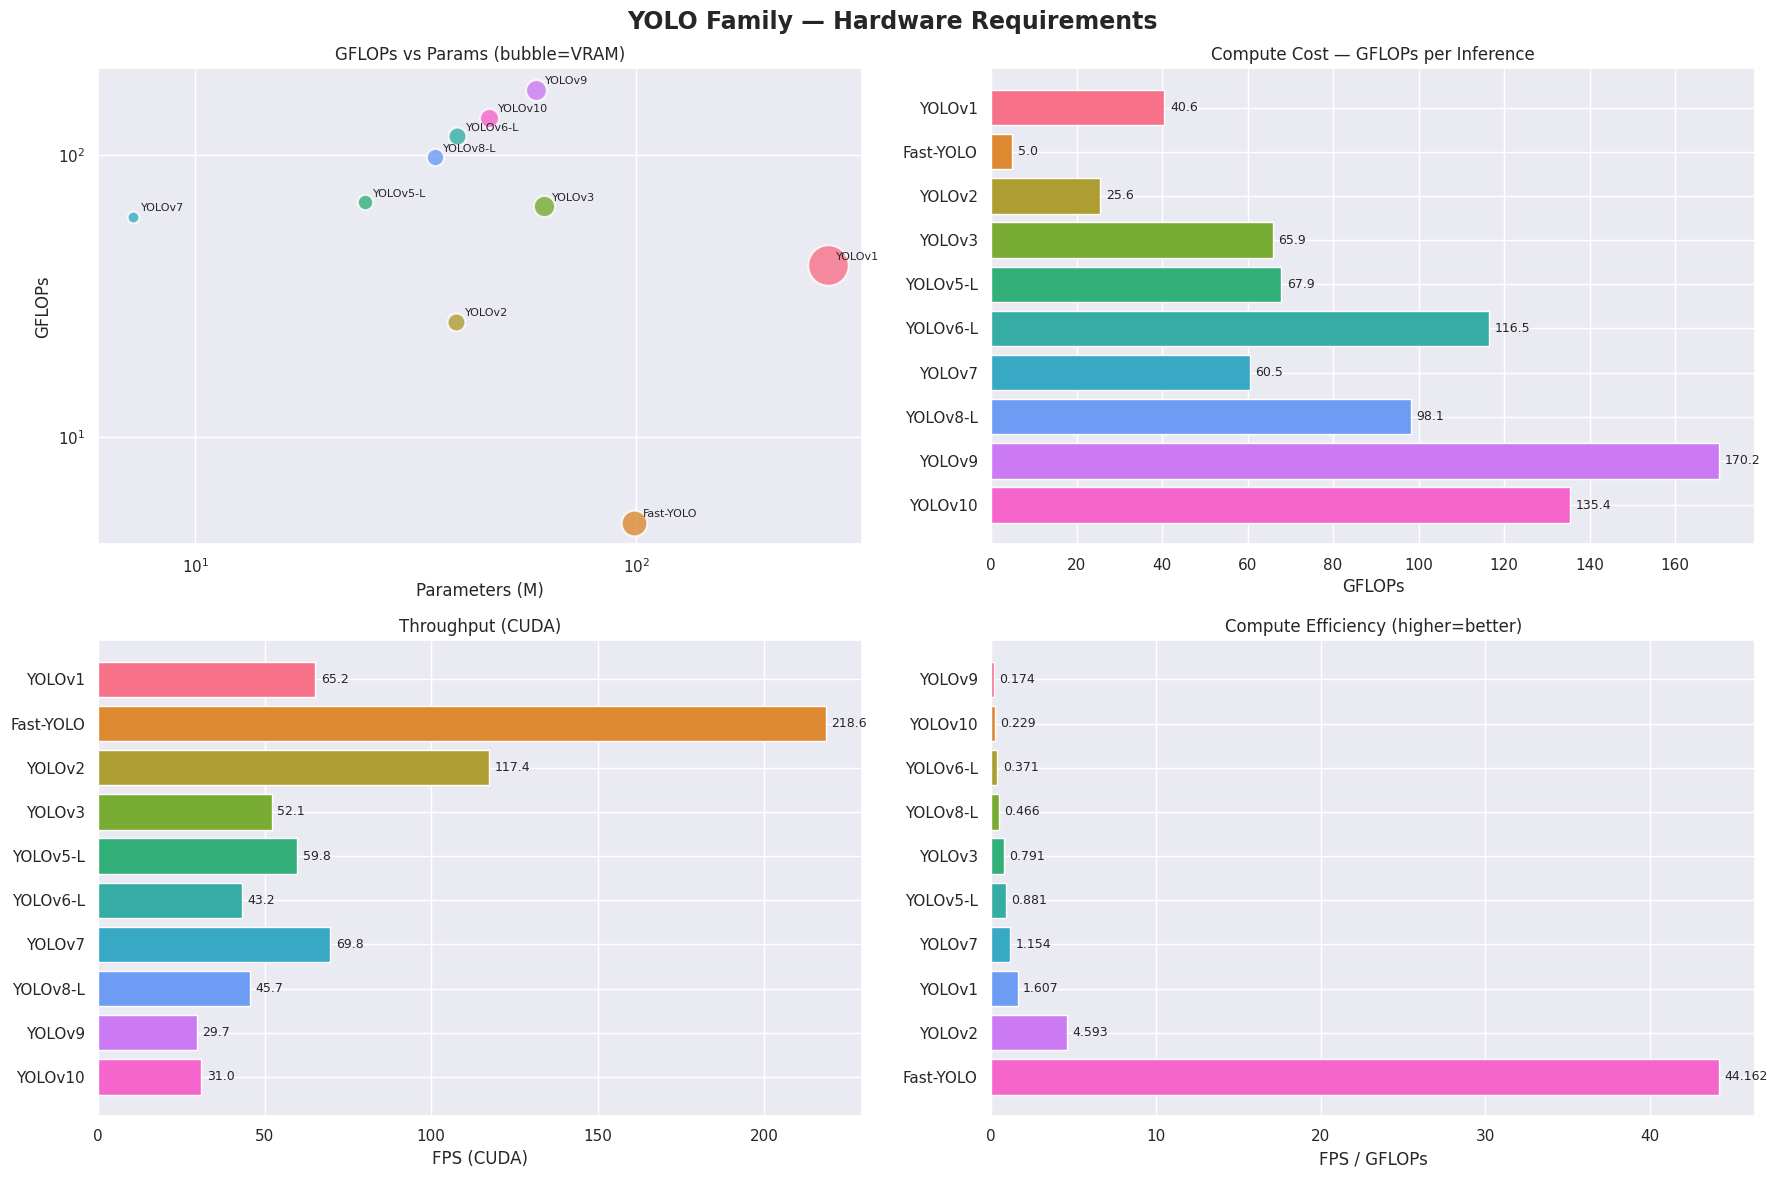

Figure saved: yolo_profile.png


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='darkgrid')

df_f = pd.DataFrame([r for r in results if r['GFLOPs'] != 'ERR'])
df_b = pd.DataFrame([r for r in bench_results if r['FPS'] != 'ERR'])
df_f['GFLOPs'] = df_f['GFLOPs'].astype(float)
df_f['Params (M)'] = df_f['Params (M)'].astype(float)
df_f['VRAM FP32 (MB)'] = df_f['VRAM FP32 (MB)'].astype(float)
df_b['FPS'] = df_b['FPS'].astype(float)
df = df_f.merge(df_b[['Model','FPS']], on='Model', how='left')
df['Efficiency'] = (df['FPS'] / df['GFLOPs']).round(4)
colors = sns.color_palette('husl', len(df))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('YOLO Family — Hardware Requirements', fontsize=17, fontweight='bold')

# 1: Bubble chart
ax = axes[0,0]
for i, row in df.iterrows():
    sz = row['VRAM FP32 (MB)'] / df['VRAM FP32 (MB)'].max() * 800 + 50
    ax.scatter(row['Params (M)'], row['GFLOPs'], s=sz, color=colors[i], alpha=0.8, edgecolors='white', lw=1.5)
    ax.annotate(row['Model'], (row['Params (M)'], row['GFLOPs']), xytext=(6,4), textcoords='offset points', fontsize=8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Parameters (M)'); ax.set_ylabel('GFLOPs')
ax.set_title('GFLOPs vs Params (bubble=VRAM)')

# 2: GFLOPs bar
ax = axes[0,1]
b = ax.barh(df['Model'], df['GFLOPs'], color=colors, edgecolor='white')
ax.bar_label(b, fmt='%.1f', padding=4, fontsize=9)
ax.set_xlabel('GFLOPs'); ax.set_title('Compute Cost — GFLOPs per Inference'); ax.invert_yaxis()

# 3: FPS bar
ax = axes[1,0]
dv = df.dropna(subset=['FPS'])
b = ax.barh(dv['Model'], dv['FPS'], color=colors[:len(dv)], edgecolor='white')
ax.bar_label(b, fmt='%.1f', padding=4, fontsize=9)
ax.set_xlabel(f'FPS ({device.upper()})'); ax.set_title(f'Throughput ({device.upper()})'); ax.invert_yaxis()

# 4: Efficiency
ax = axes[1,1]
de = df.dropna(subset=['Efficiency']).sort_values('Efficiency')
b = ax.barh(de['Model'], de['Efficiency'], color=colors[:len(de)], edgecolor='white')
ax.bar_label(b, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlabel('FPS / GFLOPs'); ax.set_title('Compute Efficiency (higher=better)'); ax.invert_yaxis()

plt.tight_layout()
plt.savefig('yolo_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: yolo_profile.png')


## Cell 6 — Export to CSV / JSON

In [ ]:
import pandas as pd, json

df_out = pd.DataFrame(results).merge(
    pd.DataFrame(bench_results)[['Model','Latency (ms)','FPS']], on='Model', how='left')

df_out.to_csv('yolo_results.csv', index=False)
df_out.to_json('yolo_results.json', orient='records', indent=2)
print('Saved: yolo_results.csv')
print('Saved: yolo_results.json')
print()
print(df_out.to_string(index=False))
print()
print('Paper-reported reference values (official implementations):')
ref = [
    ['YOLOv1',    '~40.7',  '~188',   '448x448', '63.4 VOC'],
    ['Fast-YOLO', '~3.6',   '~4.7',   '448x448', '52.7 VOC'],
    ['YOLOv2',    '~61.8',  '~50.7',  '608x608', '48.1 COCO'],
    ['YOLOv3',    '~140.7', '~61.9',  '608x608', '57.9 COCO'],
    ['YOLOv4',    '~128.5', '~52.5',  '608x608', '65.7 COCO'],
    ['YOLOv5-L',  '~135.0', '~46.5',  '640x640', '49.0 COCO'],
    ['YOLOv6-L',  '~150.7', '~58.5',  '640x640', '52.8 COCO'],
    ['YOLOv7',    '~104.7', '~36.9',  '640x640', '51.4 COCO'],
    ['YOLOv8-L',  '~165.2', '~43.7',  '640x640', '52.9 COCO'],
    ['YOLOv9-C',  '~102.1', '~25.3',  '640x640', '53.0 COCO'],
    ['YOLOv10-L', '~120.3', '~24.4',  '640x640', '53.4 COCO'],
]
print(tabulate(ref, headers=['Model','GFLOPs','Params(M)','Input','mAP'], tablefmt='fancy_grid'))
print()
print('Note: paper values use full FPN necks and multi-scale heads.')
print('Notebook values are from simplified single-branch architectures.')


## Cell 7 — System Info

In [6]:
import torch, platform, multiprocessing

print('=' * 50)
print('SYSTEM INFORMATION')
print('=' * 50)
print(f'OS          : {platform.system()} {platform.release()}')
print(f'CPU cores   : {multiprocessing.cpu_count()}')
print(f'PyTorch     : {torch.__version__}')
print(f'CUDA avail  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    g = torch.cuda.get_device_properties(0)
    print(f'GPU         : {g.name}')
    print(f'VRAM total  : {g.total_memory/1024**3:.1f} GB')
    print(f'SM count    : {g.multi_processor_count}')
    print(f'CUDA cap    : {g.major}.{g.minor}')
else:
    print('No CUDA GPU — benchmarks ran on CPU.')
    print('Run on Colab (Runtime > Change runtime type > T4 GPU) for GPU benchmarks.')
print('=' * 50)


SYSTEM INFORMATION
OS          : Linux 6.6.113+
CPU cores   : 2
PyTorch     : 2.10.0+cu128
CUDA avail  : True
GPU         : Tesla T4
VRAM total  : 14.6 GB
SM count    : 40
CUDA cap    : 7.5
